In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

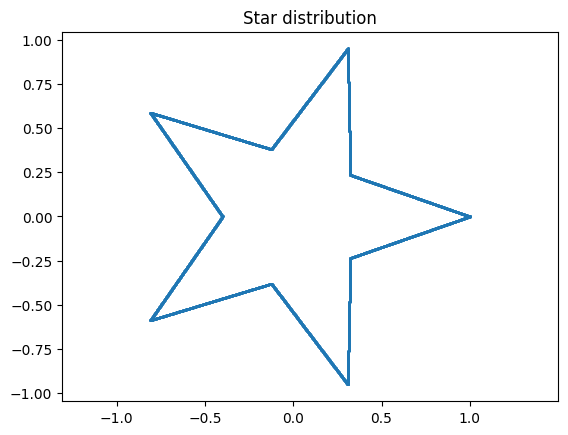

In [2]:
def make_star(num_points=5000, spikes=5, r_inner=0.4, r_outer=1.0):
    verts = []
    for k in range(2 * spikes):
        a = k * np.pi / spikes
        r = r_outer if k % 2 == 0 else r_inner
        verts.append([r * np.cos(a), r * np.sin(a)])
    verts.append(verts[0])
    verts = np.array(verts)
    pts = []
    seg = num_points // len(verts)
    for i in range(len(verts) - 1):
        for alpha in np.linspace(0, 1, seg):
            pts.append((1 - alpha) * verts[i] + alpha * verts[i + 1])
    return np.array(pts)

data_star = make_star()
plt.scatter(data_star[:, 0], data_star[:, 1], s=1)
plt.axis('equal')
plt.title('Star distribution')
plt.show()

In [3]:
def alpha_bar_lin(t, bmin=0.1, bmax=20.0):
    return torch.clamp(torch.exp(-(bmin * t + 0.5 * (bmax - bmin) * t ** 2)), 1e-5, 1 - 1e-5)

def beta_lin(t, bmin=0.1, bmax=20.0):
    return bmin + (bmax - bmin) * t

def alpha_bar_cos(t, s=0.008):
    f = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
    f0 = math.cos(s / (1 + s) * math.pi / 2) ** 2
    return torch.clamp(f / f0, 1e-5, 1 - 1e-5)

def beta_cos(t, s=0.008, clip=20.0):
    return torch.clamp(
        math.pi / (1 + s) * torch.tan((t + s) / (1 + s) * math.pi / 2),
        1e-6, clip
    )

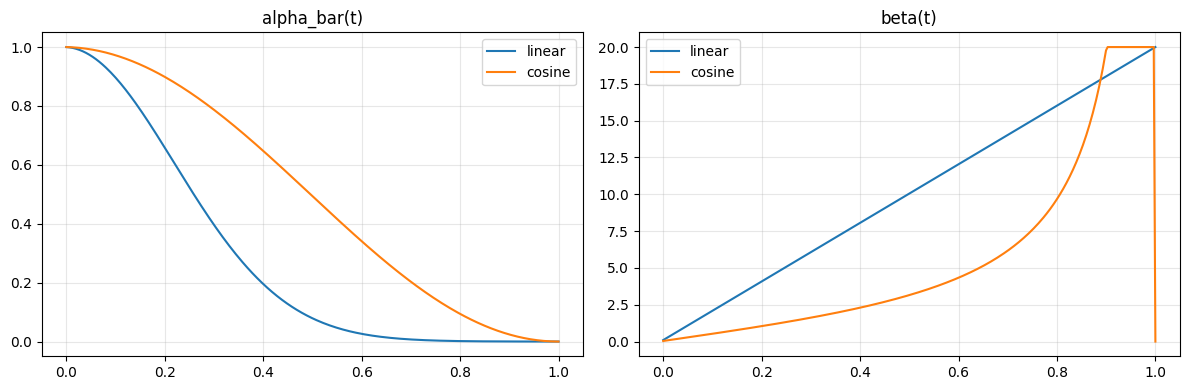

In [4]:
ts = torch.linspace(0, 1, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for label, ab_fn, b_fn in [('linear', alpha_bar_lin, beta_lin), ('cosine', alpha_bar_cos, beta_cos)]:
    ax1.plot(ts.numpy(), ab_fn(ts).numpy(), label=label)
    ax2.plot(ts.numpy(), b_fn(ts).numpy(), label=label)
ax1.set_title('alpha_bar(t)')
ax1.legend()
ax1.grid(alpha=0.3)
ax2.set_title('beta(t)')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
class NoisePredictor(nn.Module):
    def __init__(self, dim=2, hdim=256):
        super().__init__()
        self.t_mlp = nn.Sequential(
            nn.Linear(1, hdim),
            nn.SiLU(),
            nn.Linear(hdim, hdim),
        )
        self.body = nn.Sequential(
            nn.Linear(dim + hdim, hdim),
            nn.SiLU(),
            nn.Linear(hdim, hdim),
            nn.SiLU(),
            nn.Linear(hdim, dim),
        )

    def forward(self, x, t):
        return self.body(torch.cat([x, self.t_mlp(t)], 1))

In [6]:
def flat_weight(ab, bt, t):
    return torch.ones_like(t)

def snr_weight(ab, bt, t):
    return torch.clamp(ab / (1 - ab + 1e-5), max=5.0)

def beta_weight(ab, bt, t):
    return bt

In [7]:
N_EPOCHS = 2000
BATCH = 512
LR = 1e-3
N_STEPS = 1000

def run_experiment(ab_fn, b_fn, w_fn):
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    xy = torch.tensor(make_star(), dtype=torch.float32)
    loader = DataLoader(TensorDataset(xy), batch_size=BATCH, shuffle=True)

    model = NoisePredictor().to(dev)
    opt = optim.Adam(model.parameters(), lr=LR)
    loss_curve = []

    for epoch in range(N_EPOCHS):
        model.train()
        acc = 0.0
        for (batch,) in loader:
            batch = batch.to(dev)
            t = torch.rand(len(batch), 1, device=dev).clamp(1e-5, 1 - 1e-5)
            ab = ab_fn(t)
            eps = torch.randn_like(batch)
            xt = batch * ab.sqrt() + eps * (1 - ab).sqrt()
            pred = model(xt, t)
            loss = (w_fn(ab, b_fn(t), t) * (pred - eps).pow(2)).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            acc += loss.item() * len(batch)
        loss_curve.append(acc / len(xy))
        if epoch % 500 == 0:
            print(f'  [{epoch}] loss={loss_curve[-1]:.5f}')

    model.eval()
    with torch.no_grad():
        x = torch.randn(1000, 2, device=dev)
        dt = 1.0 / N_STEPS
        for step in range(N_STEPS):
            tc = max(1.0 - step * dt, 1e-5)
            tv = torch.full((1000, 1), tc, device=dev)
            ab = ab_fn(tv)
            bt = b_fn(tv)
            sc = -model(x, tv) / (1 - ab).sqrt()
            x = x + (0.5 * bt * x + bt * sc) * dt
            if step < N_STEPS - 1:
                x = x + (bt * dt).sqrt() * torch.randn_like(x)
    return model, loss_curve, x.cpu().numpy()

In [8]:
schedule_map = {
    'linear': (alpha_bar_lin, beta_lin),
    'cosine': (alpha_bar_cos, beta_cos),
}
weight_map = {
    'uniform': flat_weight,
    'snr': snr_weight,
    'likelihood': beta_weight,
}

runs = {}
for sn, (ab, bt) in schedule_map.items():
    for wn, wf in weight_map.items():
        tag = f'{sn}_{wn}'
        print(f'\n>>> {tag}')
        m, lc, pts = run_experiment(ab, bt, wf)
        runs[tag] = {'loss': lc, 'pts': pts}
        print(f'  final loss: {lc[-1]:.5f}')


>>> linear_uniform
  [0] loss=0.91468
  [500] loss=0.17308
  [1000] loss=0.17258
  [1500] loss=0.16236
  final loss: 0.14967

>>> linear_snr
  [0] loss=1.05876
  [500] loss=0.56352
  [1000] loss=0.56190
  [1500] loss=0.61526
  final loss: 0.54624

>>> linear_likelihood
  [0] loss=8.89932
  [500] loss=0.45144
  [1000] loss=0.47155
  [1500] loss=0.46613
  final loss: 0.47464

>>> cosine_uniform
  [0] loss=0.93648
  [500] loss=0.33816
  [1000] loss=0.29025
  [1500] loss=0.28728
  final loss: 0.28958

>>> cosine_snr
  [0] loss=1.88280
  [500] loss=1.14621
  [1000] loss=1.18341
  [1500] loss=1.05183
  final loss: 1.02036

>>> cosine_likelihood
  [0] loss=5.33988
  [500] loss=0.45530
  [1000] loss=0.47034
  [1500] loss=0.45718
  final loss: 0.45219


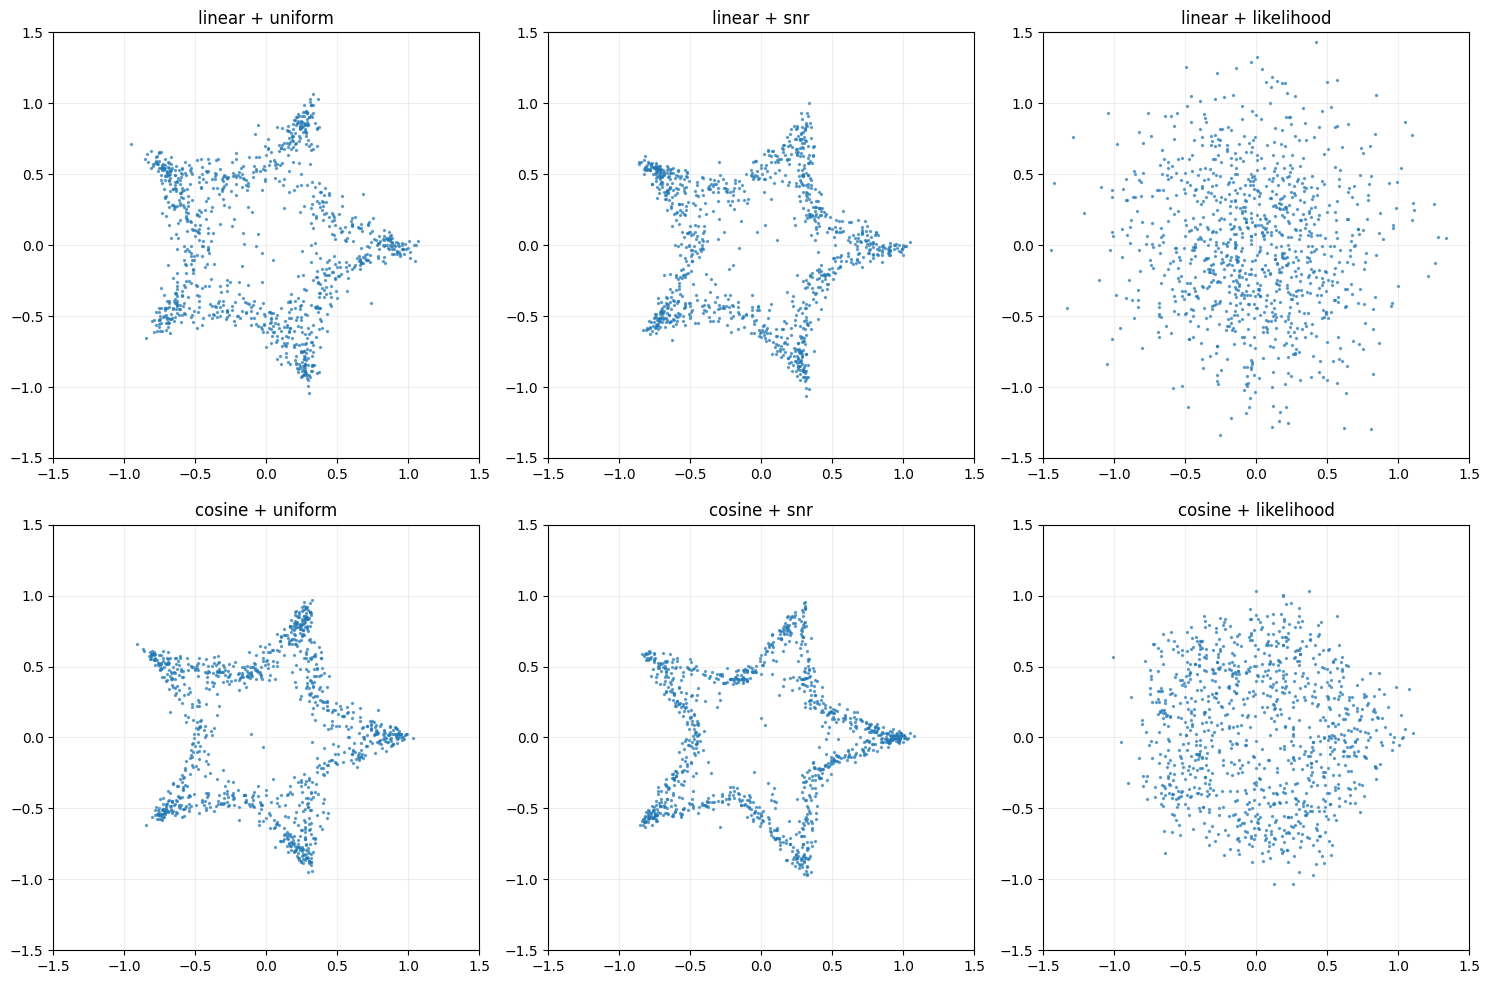

In [9]:
sched_list = ['linear', 'cosine']
weight_list = ['uniform', 'snr', 'likelihood']

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
for r, sn in enumerate(sched_list):
    for c, wn in enumerate(weight_list):
        p = runs[f'{sn}_{wn}']['pts']
        ax[r][c].scatter(p[:, 0], p[:, 1], s=2, alpha=0.6)
        ax[r][c].set_title(f'{sn} + {wn}')
        ax[r][c].set_xlim(-1.5, 1.5)
        ax[r][c].set_ylim(-1.5, 1.5)
        ax[r][c].set_aspect('equal')
        ax[r][c].grid(alpha=0.2)
plt.tight_layout()
plt.show()

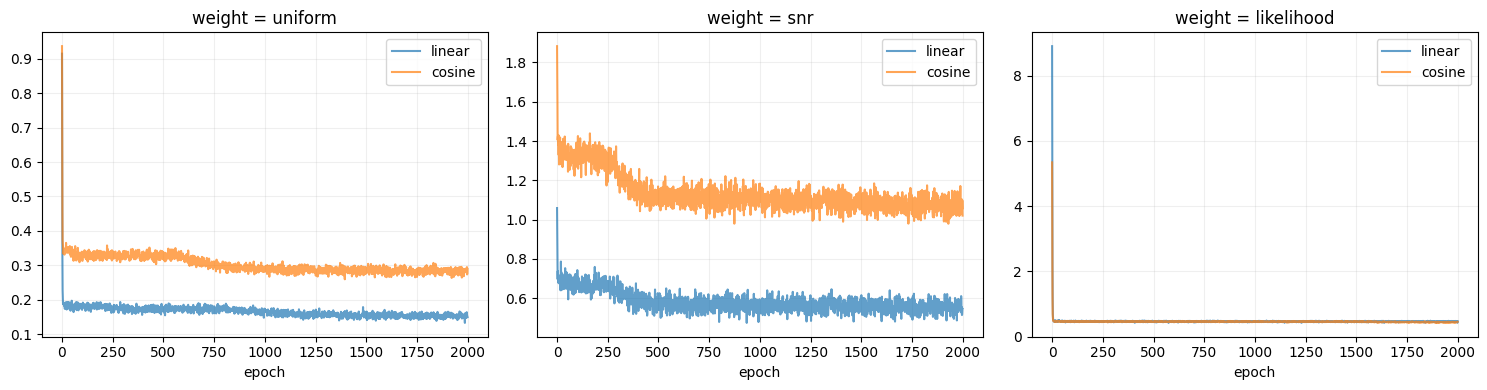

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for c, wn in enumerate(weight_list):
    for sn in sched_list:
        ax[c].plot(runs[f'{sn}_{wn}']['loss'], label=sn, alpha=0.7)
    ax[c].set_title(f'weight = {wn}')
    ax[c].set_xlabel('epoch')
    ax[c].legend()
    ax[c].grid(alpha=0.2)
plt.tight_layout()
plt.show()

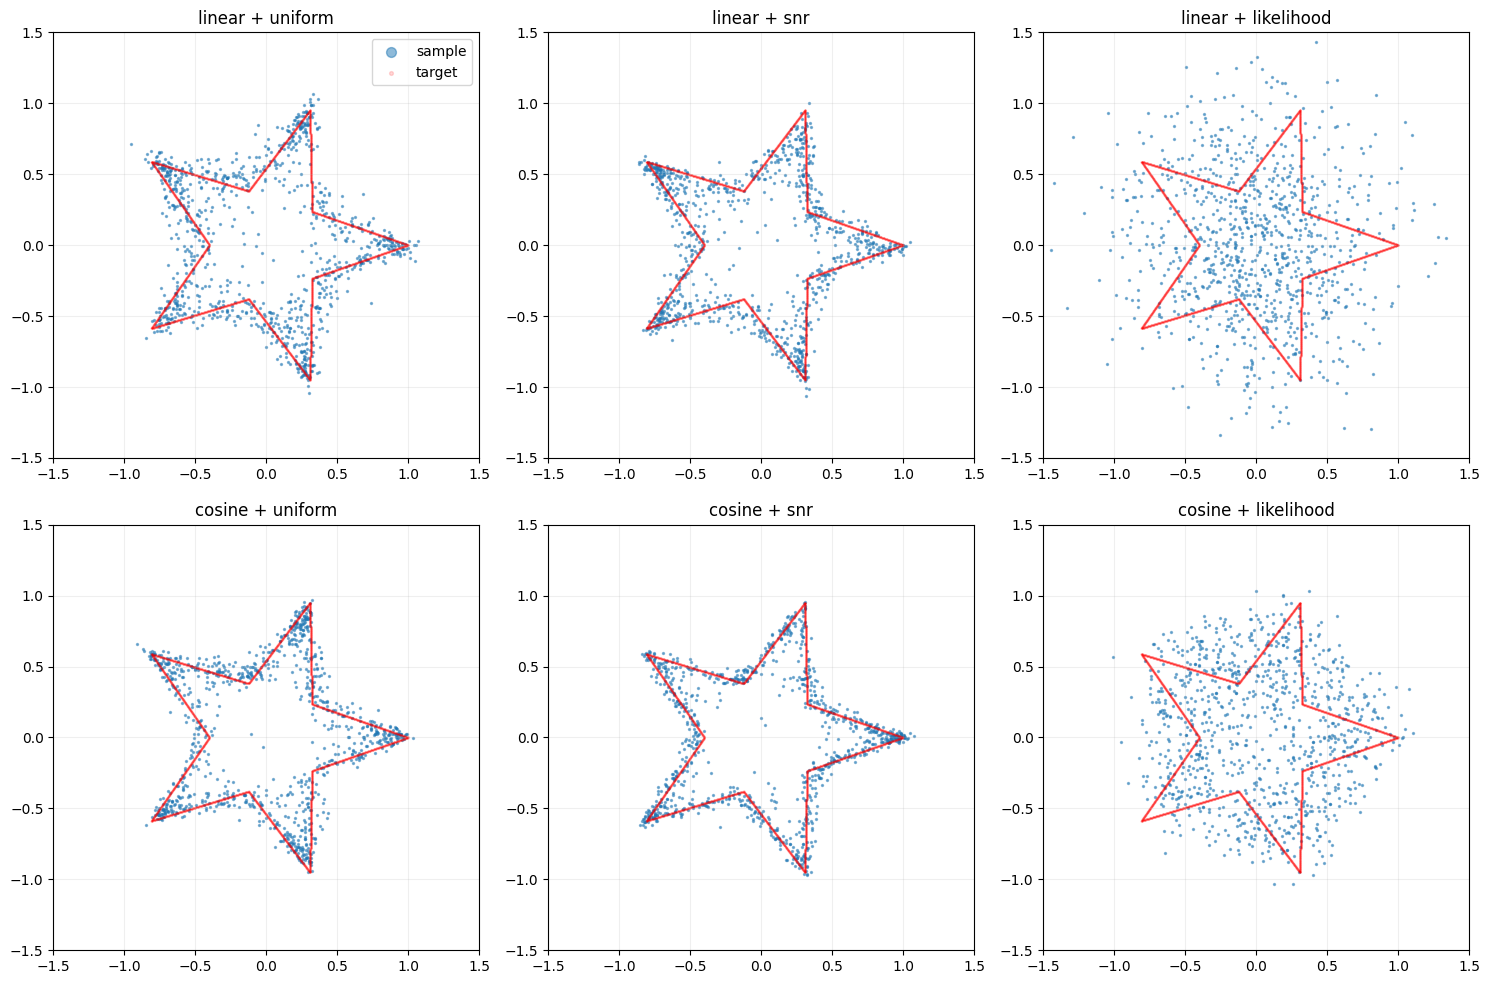

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
for c, wn in enumerate(weight_list):
    for r, sn in enumerate(sched_list):
        p = runs[f'{sn}_{wn}']['pts']
        ax[r][c].scatter(p[:, 0], p[:, 1], s=2, alpha=0.5, label='sample')
        ax[r][c].scatter(data_star[:, 0], data_star[:, 1], s=0.3, alpha=0.15, c='red', label='target')
        ax[r][c].set_title(f'{sn} + {wn}')
        ax[r][c].set_xlim(-1.5, 1.5)
        ax[r][c].set_ylim(-1.5, 1.5)
        ax[r][c].set_aspect('equal')
        ax[r][c].grid(alpha=0.2)
        if r == 0 and c == 0:
            ax[r][c].legend(markerscale=5)
plt.tight_layout()
plt.show()

При косинусовом расписании alpha_bar убывает более плавно, из-за чего модель получает более разнообразные уровни зашумления в процессе обучения. Это особенно заметно на лучах звезды, где косинусовое расписание точнее передает геометрию кончиков

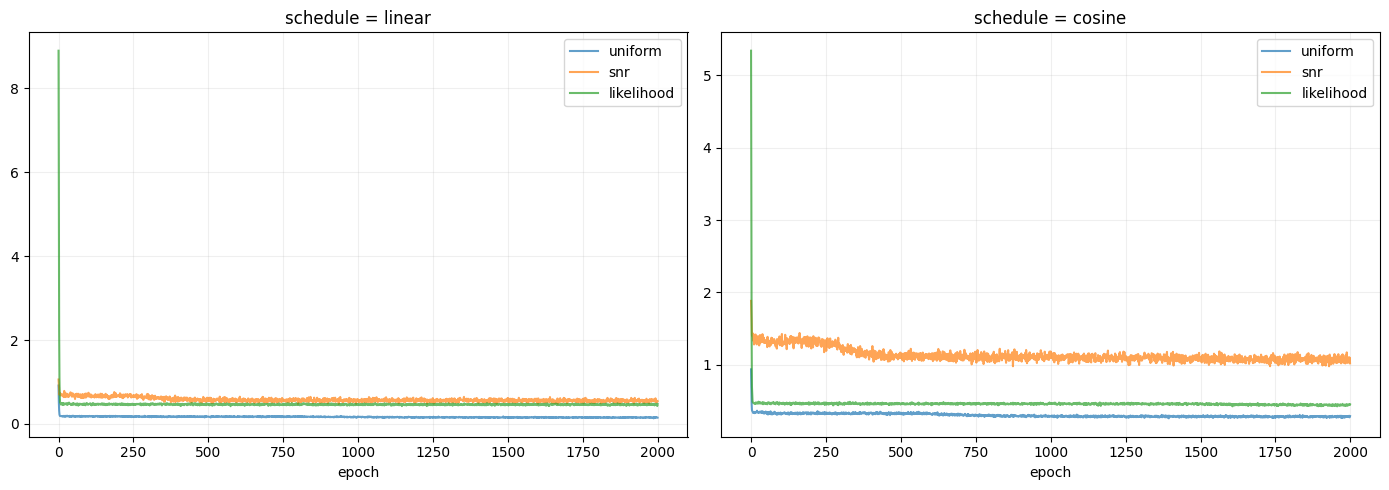

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, sn in enumerate(sched_list):
    for wn in weight_list:
        ax[i].plot(runs[f'{sn}_{wn}']['loss'], label=wn, alpha=0.7)
    ax[i].set_title(f'schedule = {sn}')
    ax[i].set_xlabel('epoch')
    ax[i].legend()
    ax[i].grid(alpha=0.2)
plt.tight_layout()
plt.show()

Uniform дает стабильный baseline, SNR-перевзвешивание акцентирует обучение на слабо зашумленных шагах и улучшает детализацию формы, а likelihood-перевзвешивание через beta смещает фокус на сильно зашумленные шаги и помогает модели лучше восстанавливать глобальное расположение точек, что правда сильно зашумляет результат

## Вывод

VP-SDE диффузионная модель воспроизводит звездочку во всех шести вариантах, кроме разве что likelihood вариантов. Наилучшее визуальное качество достигается при косинусовом расписании в сочетании с SNR-перевзвешиванием, поскольку эта комбинация обеспечивает и равномерное покрытие уровней шума, и акцент на точках с высоким отношением сигнал/шум